In [1]:
# CÀI ĐẶT VÀ IMPORT CÁC THƯ VIỆN CẦN THIẾT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
# 1. Tải bộ dữ liệu titanic
titanic = sns.load_dataset('titanic')

# In ra 5 dòng đầu tiên
print("--- 5 DÒNG ĐẦU TIÊN CỦA DỮ LIỆU ---")
display(titanic.head())

# 2. In ra thông tin tổng quan của dữ liệu
print("\n--- THÔNG TIN TỔNG QUAN ---")
titanic.info()

--- 5 DÒNG ĐẦU TIÊN CỦA DỮ LIỆU ---


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



--- THÔNG TIN TỔNG QUAN ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [3]:
# 1. Đếm số lượng giá trị khuyết ở mỗi cột
print("--- SỐ LƯỢNG GIÁ TRỊ KHUYẾT TRƯỚC KHI XỬ LÝ ---")
print(titanic.isnull().sum())

# 2. Xóa hoàn toàn cột 'deck'
titanic = titanic.drop(columns=['deck'])

# 3. Điền giá trị khuyết cột 'age' bằng giá trị Trung bình (Mean)
mean_age = titanic['age'].mean()
titanic['age'] = titanic['age'].fillna(mean_age)

# Kiểm tra lại xem còn giá trị khuyết ở cột age không
print("\n--- SỐ LƯỢNG GIÁ TRỊ KHUYẾT SAU KHI XỬ LÝ ---")
print(titanic.isnull().sum())

--- SỐ LƯỢNG GIÁ TRỊ KHUYẾT TRƯỚC KHI XỬ LÝ ---
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

--- SỐ LƯỢNG GIÁ TRỊ KHUYẾT SAU KHI XỬ LÝ ---
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       2
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


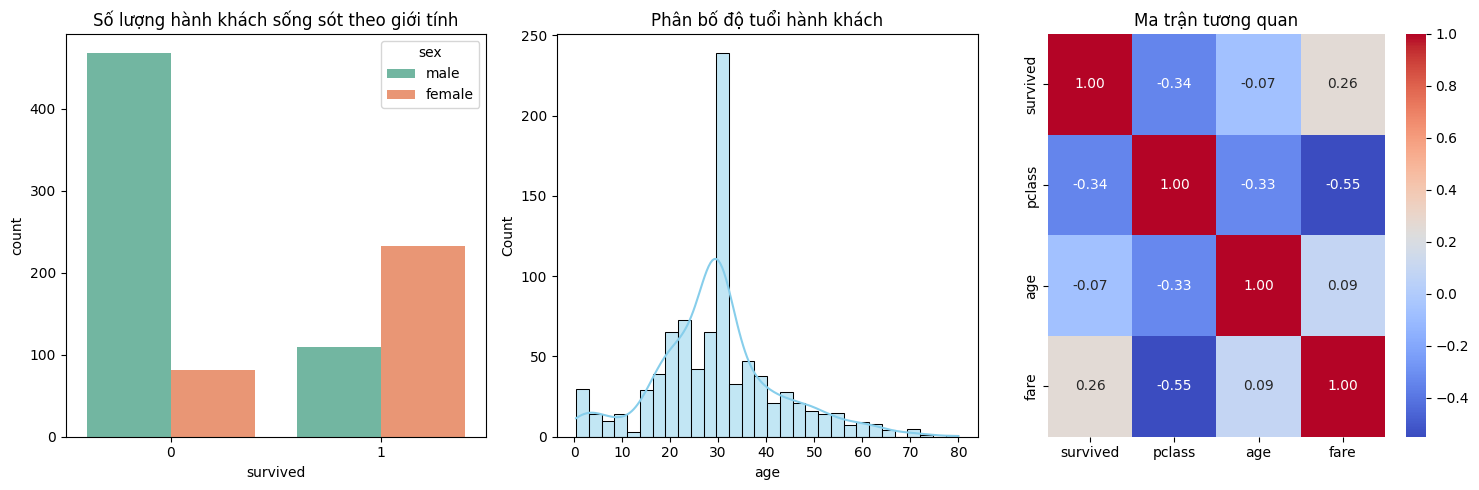

In [4]:
# Cấu hình kích thước biểu đồ cho dễ nhìn
plt.figure(figsize=(15, 5))

# 1. Biểu đồ đếm số lượng hành khách sống sót phân chia theo giới tính
plt.subplot(1, 3, 1)
sns.countplot(data=titanic, x='survived', hue='sex', palette='Set2')
plt.title('Số lượng hành khách sống sót theo giới tính')

# 2. Biểu đồ phân bố độ tuổi
plt.subplot(1, 3, 2)
sns.histplot(data=titanic, x='age', kde=True, color='skyblue', bins=30)
plt.title('Phân bố độ tuổi hành khách')

# 3. Ma trận tương quan giữa các biến số dạng số
plt.subplot(1, 3, 3)
numeric_cols = titanic[['survived', 'pclass', 'age', 'fare']]
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan')

# Hiển thị tất cả các biểu đồ
plt.tight_layout()
plt.show()

In [5]:
# 1. Label Encoding cho cột 'sex' ('male': 0, 'female': 1)
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})

# 2. One-Hot Encoding cho cột 'embarked'
titanic = pd.get_dummies(titanic, columns=['embarked'], dtype=int)

# Xem qua dữ liệu sau khi mã hóa
print("--- DỮ LIỆU SAU KHI MÃ HÓA ---")
display(titanic[['sex', 'embarked_C', 'embarked_Q', 'embarked_S']].head())

--- DỮ LIỆU SAU KHI MÃ HÓA ---


,sex,embarked_C,embarked_Q,embarked_S
0,0,0,0,1
1,1,1,0,0
2,1,0,0,1
3,1,0,0,1
4,0,0,0,1


In [6]:
# 1. Tạo biến X và y
X = titanic[['pclass', 'sex', 'age']]
y = titanic['survived']

# 2. Chia dữ liệu thành tập train và test (tỷ lệ 80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Chuẩn hóa (Scale) tập X_train và X_test bằng StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Kích thước tập huấn luyện (X_train): {X_train.shape}")
print(f"Kích thước tập kiểm thử (X_test): {X_test.shape}")

Kích thước tập huấn luyện (X_train): (712, 3)
Kích thước tập kiểm thử (X_test): (179, 3)


In [7]:
# 1. Khởi tạo mô hình Sequential
model = Sequential()

# 2. Thêm lớp ẩn với 16 nơ-ron, activation='relu', input_shape=(3,)
model.add(Dense(16, activation='relu', input_shape=(3,)))

# 3. Thêm lớp đầu ra với 1 nơ-ron, activation='sigmoid'
model.add(Dense(1, activation='sigmoid'))

# 4. Compile mô hình
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Xem tóm tắt kiến trúc mô hình
model.summary()

# 5. Huấn luyện mô hình với 20 epochs
print("\n--- BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH ---")
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

# Đánh giá trên tập test
print("\n--- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---")
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Độ chính xác (Accuracy): {accuracy * 100:.2f}%")
print(f"Độ mất mát (Loss): {loss:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)


--- BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH ---
Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.6891 - loss: 0.6400 - val_accuracy: 0.7083 - val_loss: 0.6192
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7031 - loss: 0.6114 - val_accuracy: 0.7361 - val_loss: 0.5823
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7203 - loss: 0.5877 - val_accuracy: 0.7639 - val_loss: 0.5508
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7312 - loss: 0.5676 - val_accuracy: 0.7917 - val_loss: 0.5234
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7375 - loss: 0.5509 - val_accuracy: 0.8056 - val_loss: 0.4996
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7531 - loss: 0.5365 - val_accuracy: 0.8194 - val_loss: 0.4784
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7578 - loss: 0.5243 - val_accuracy: 0.8194 - val_loss: 0.4590
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7625 - loss: 0.51